### House Price Prediction


- Aim : The objective of this project is to build a machine learning model that accurately predicts house prices based on property features.

### 1. Import Libraries

In [62]:
##import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

import warnings
warnings.filterwarnings("ignore")


### 2. Load Dataset

In [63]:
#upload dataset
df = pd.read_csv("data/Housing.csv")


### 3. Quick Data Overview

In [64]:
#view data 
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



- **price** : House price (Target)
- **area** : House area 
- **bedrooms** : Number of bedrooms 
- **bathrooms** : Number of bathrooms 
- **stories** : Number of floors 
- **mainroad** : Main road access (Yes/No) 
- **guestroom** : Guest room (Yes/No) 
- **basement** : Basement (Yes/No) 
- **hotwaterheating** : Hot water heating (Yes/No) 
- **airconditioning** : Air conditioning (Yes/No) 
- **parking** : Parking spaces 
- **prefarea** : Preferred area (Yes/No) 
- **furnishingstatus** : Furnishing status 

- The dataset contains 13 features, including both numerical and categorical variables.
- The target variable is price, which represents the house price.
- Numerical features include area, bedrooms, bathrooms, stories, and parking.
- Categorical features such as mainroad, guestroom, basement, airconditioning, prefarea, and furnishingstatus describe the amenities and condition of each house.

In [65]:
df.shape

(545, 13)

- The dataset contains **545 rows** and **13 columns**.

In [66]:
df.size

7085

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


### 4. Data Quality Check

In [68]:
df[df.duplicated()].shape

(0, 13)

- No duplicate records were found in the dataset.

In [69]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

- No missing values were found in any column.

In [42]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000



- The average house price is approximately **4.77 million**, with prices ranging from **1.75 million** to **13.30 million**.
- The average house area is **5,151 sq. ft.**, ranging from **1,650** to **16,200 sq. ft.**
- Most houses have **3 bedrooms**, **1 bathroom**, and **2 stories**.
- Parking spaces range from **0 to 3**, with an average of less than **1 parking space** per house.


In [71]:
df.skew(numeric_only=True)

price        1.212239
area         1.321188
bedrooms     0.495684
bathrooms    1.589264
stories      1.082088
parking      0.842062
dtype: float64

### 5. Distribution Visualization (Numerical Columns)

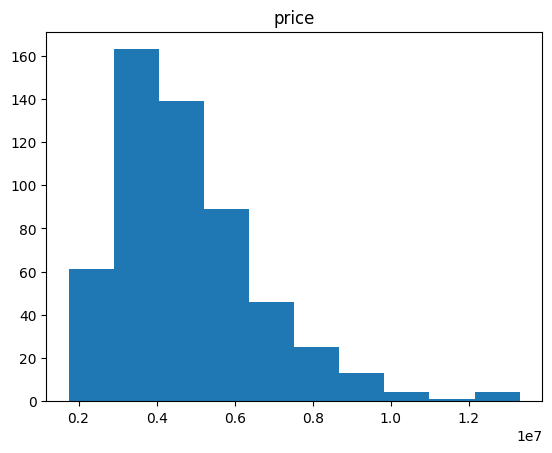

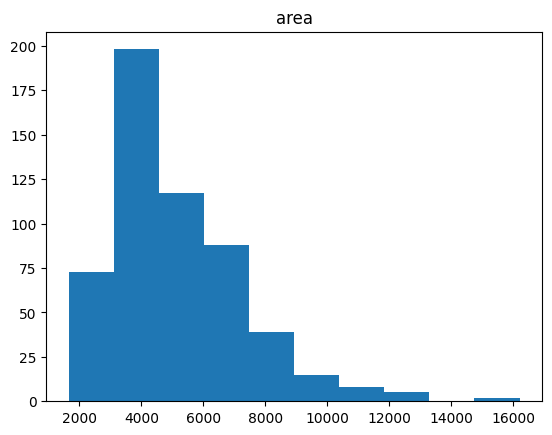

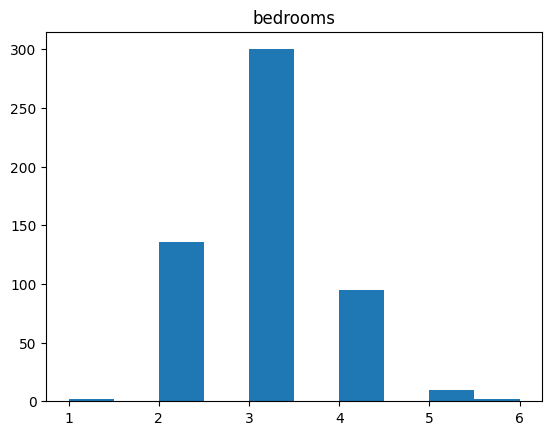

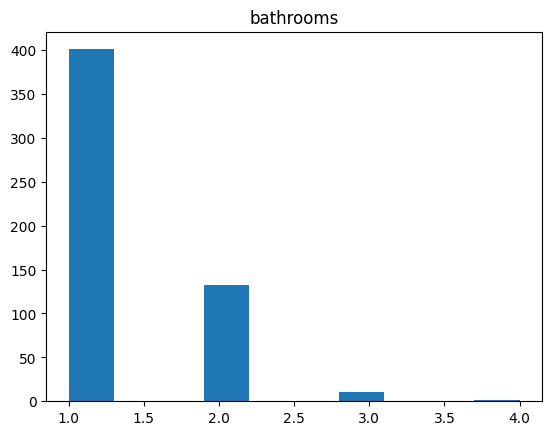

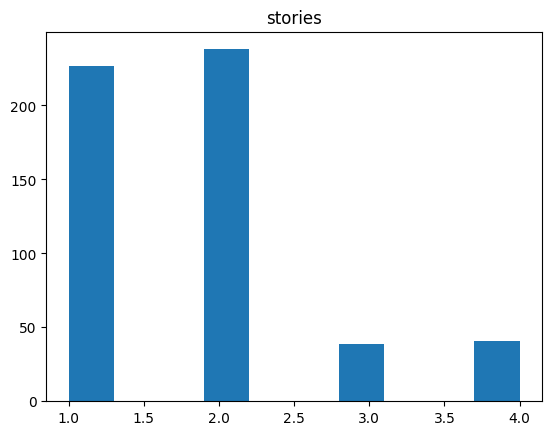

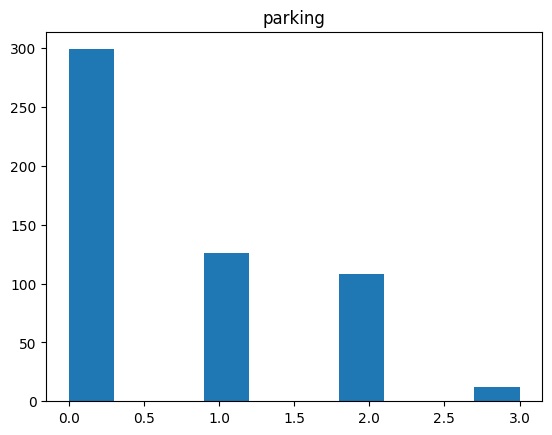

In [73]:
numeric_cols = ["price","area","bedrooms","bathrooms","stories","parking"]
for i in numeric_cols:
    plt.hist(df[i])
    plt.title(i)
    plt.show()

### 6. Unique Value Analysis

In [74]:
df.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

In [75]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(col)
        print(df[col].value_counts())
        print("-"*50)

bedrooms
bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64
--------------------------------------------------
bathrooms
bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64
--------------------------------------------------
stories
stories
2    238
1    227
4     41
3     39
Name: count, dtype: int64
--------------------------------------------------
mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64
--------------------------------------------------
guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64
--------------------------------------------------
basement
basement
no     354
yes    191
Name: count, dtype: int64
--------------------------------------------------
hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
--------------------------------------------------
airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64
-------------------------

In [76]:
data_num = df.select_dtypes(include=np.number)
data_cat = df.select_dtypes(exclude=np.number)

In [77]:
data_num

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


In [78]:
data_cat

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


### 7. Outlier Detection (Boxplot)

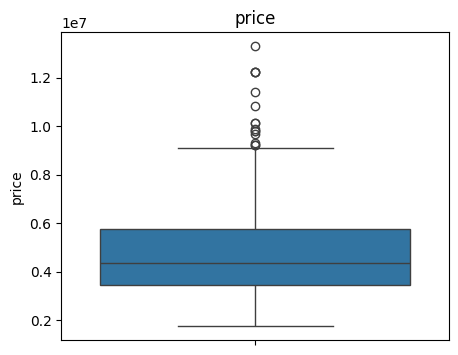

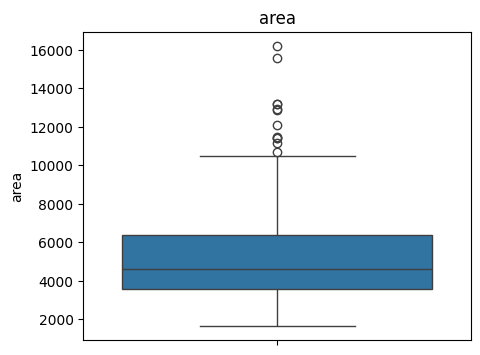

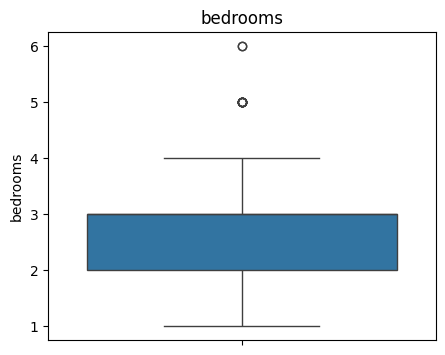

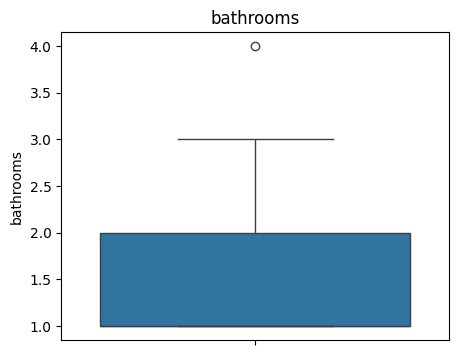

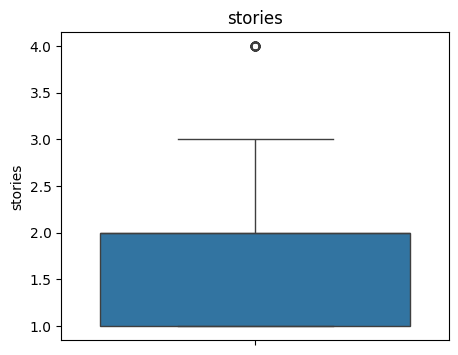

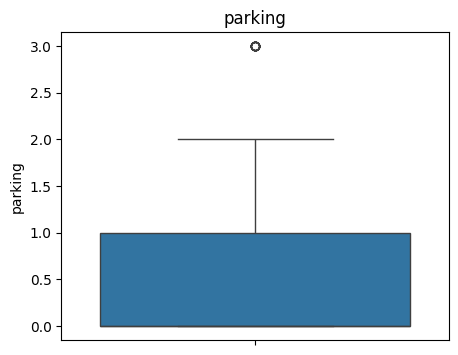

In [85]:
for i in data_num.columns:
    plt.figure(figsize=(5,4))
    sns.boxplot(data_num[i])
    plt.title(i)
    plt.show()

In [86]:
# cols = ["area","bedrooms","bathrooms","stories","parking"]
# original_shape = df.shape

# for col in cols:

#     q1 = df[col].quantile(0.25)
#     q3 = df[col].quantile(0.75)
    
#     iqr = q3-q1

#     lower = q1-1.5*iqr
#     upper = q3+1.5*iqr

#     df= df[(df[col]>=lower) & (df[col]<=upper)]

# print("Original shape:",original_shape)
# print("After Outlier Removal:",df.shape)


- Outliers are present in several numerical features.
- **Price** and **area** contain the highest number of outliers, indicating a few houses with exceptionally high prices and larger areas.
- **Bedrooms**, **bathrooms**, **stories**, and **parking** contain only a few potential outliers.
- These outliers may represent genuine high-value properties rather than data errors.


### 9. Distribution + Normality Check
- Histograms help visualize the distribution of each numerical feature.
- Q-Q plots are used to assess whether the data follows a normal distribution.


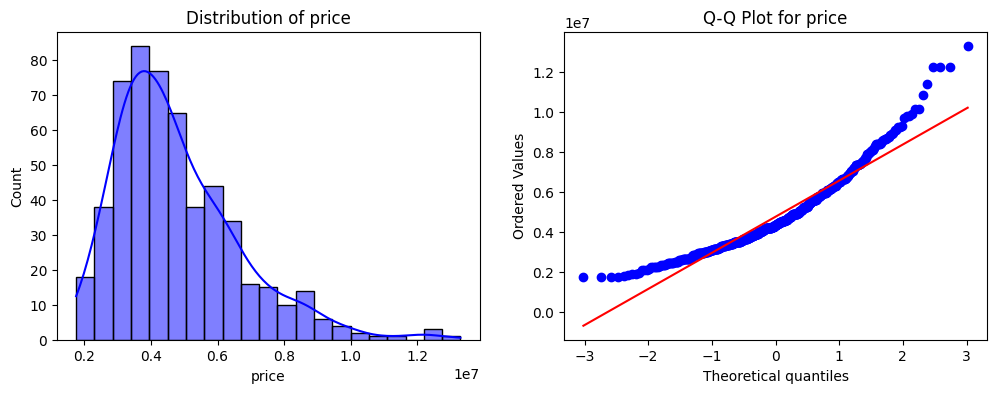

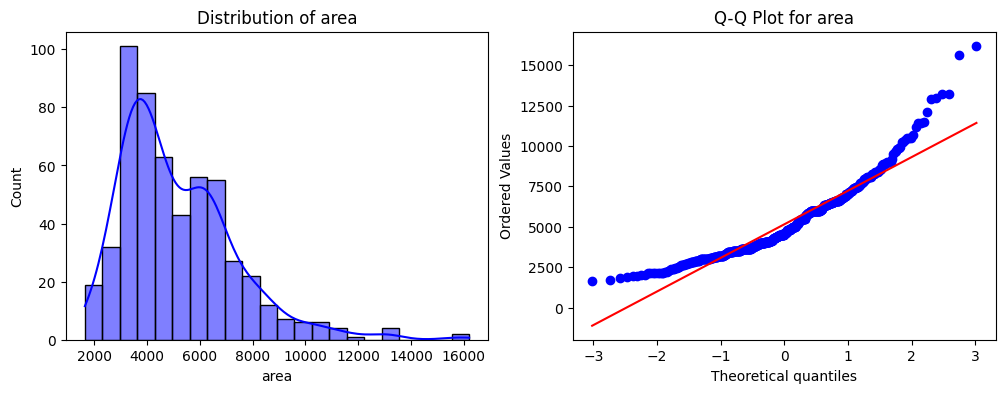

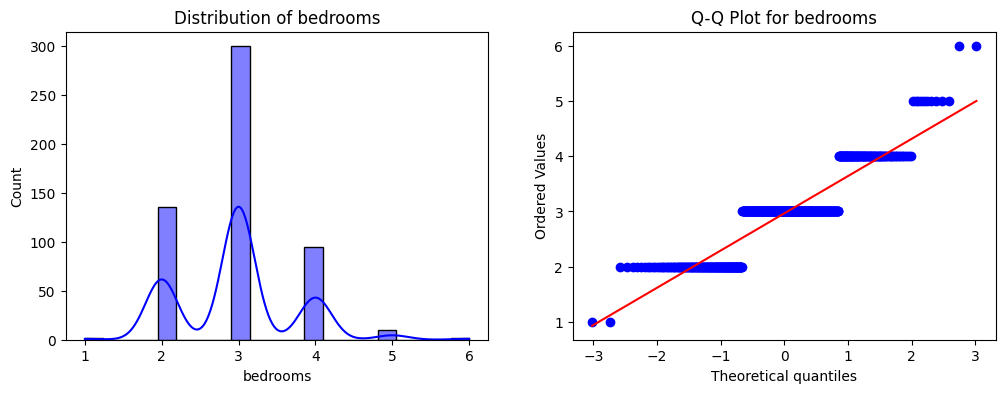

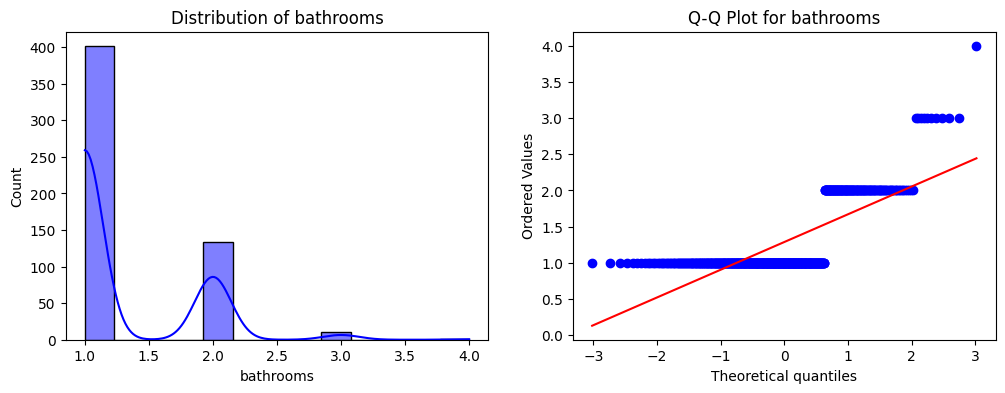

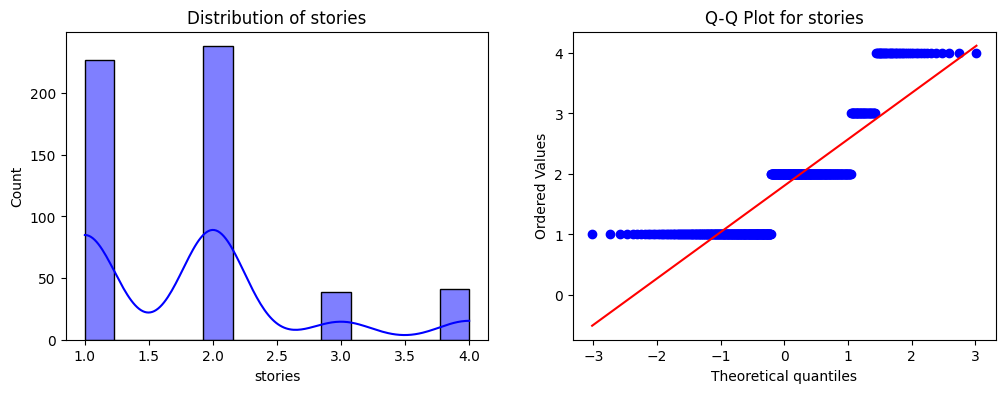

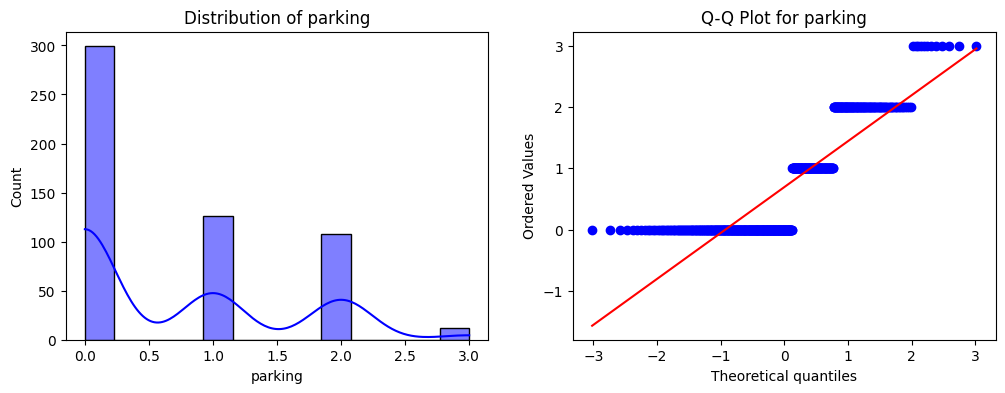

In [93]:
#from scipy import stats
for col in numeric_cols:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Distribution of {col}')
    
    plt.subplot(1, 2, 2)
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot for {col}')
    plt.show()

### 10. Categorical Feature Analysis


 Frequency counts for mainroad:
 mainroad
yes    468
no      77
Name: count, dtype: int64


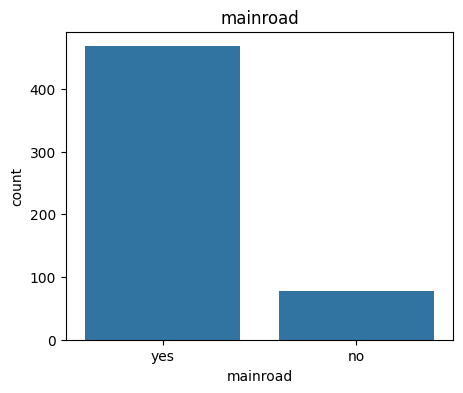


 Frequency counts for guestroom:
 guestroom
no     448
yes     97
Name: count, dtype: int64


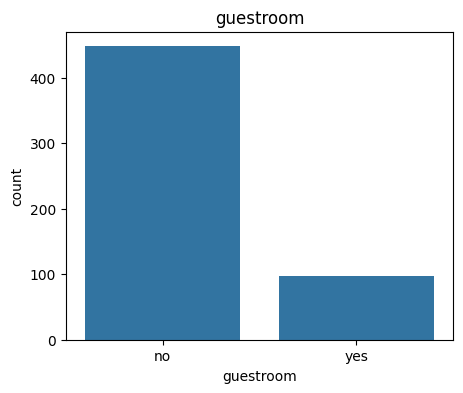


 Frequency counts for basement:
 basement
no     354
yes    191
Name: count, dtype: int64


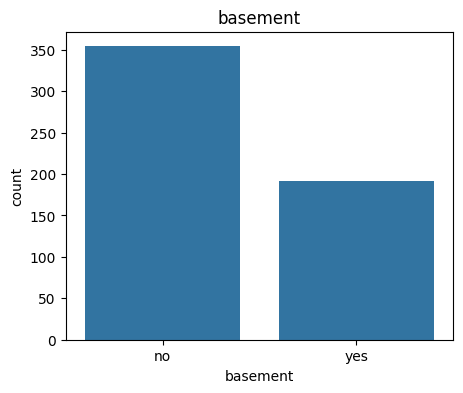


 Frequency counts for hotwaterheating:
 hotwaterheating
no     520
yes     25
Name: count, dtype: int64


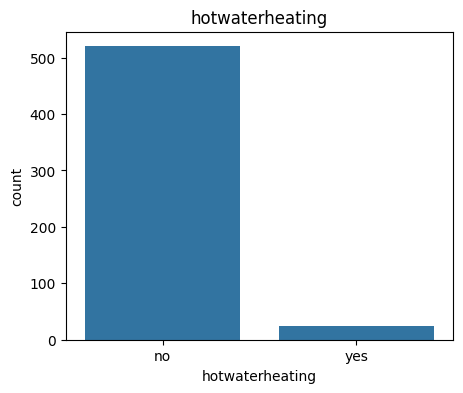


 Frequency counts for airconditioning:
 airconditioning
no     373
yes    172
Name: count, dtype: int64


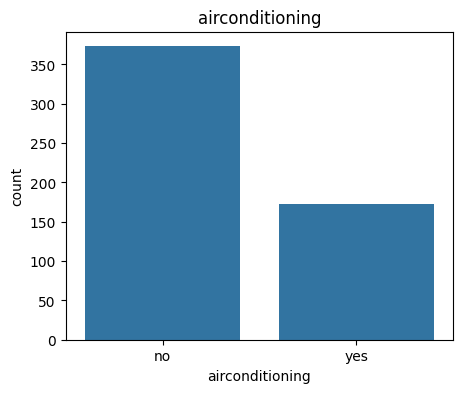


 Frequency counts for prefarea:
 prefarea
no     417
yes    128
Name: count, dtype: int64


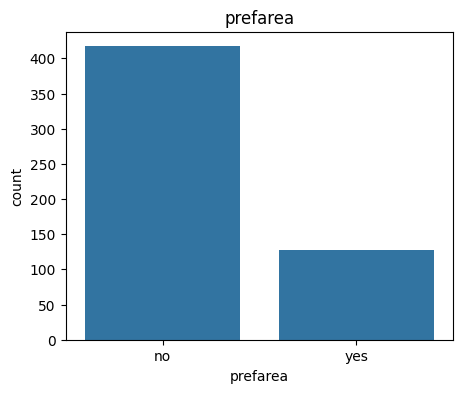


 Frequency counts for furnishingstatus:
 furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


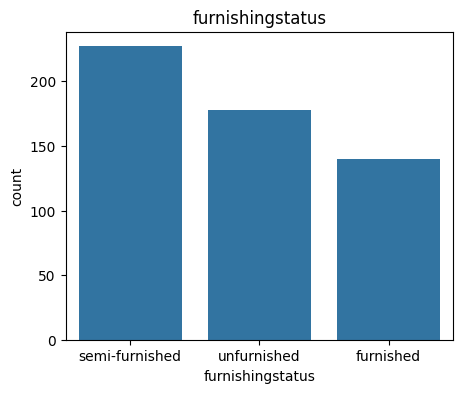

In [94]:
cat_cols = df.select_dtypes(include='object').columns

for index, col in enumerate(cat_cols):
    print(f"\n Frequency counts for {col}:\n", df[col].value_counts())
    plt.figure(figsize=(5,4))
    sns.countplot(x =col,data=df,order=df[col].value_counts().index)
    plt.title(col)
    plt.show()

### 11. Feature Relationship Analysis

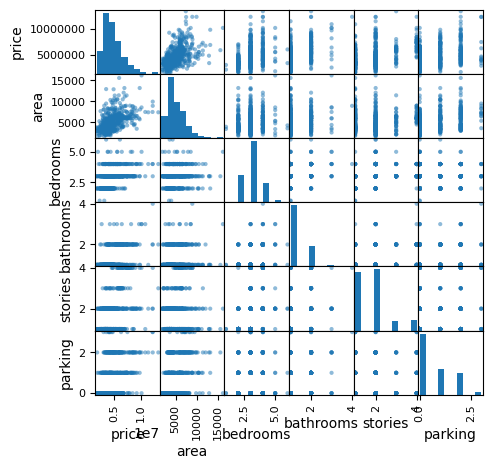

In [95]:
from pandas.plotting import scatter_matrix
p=scatter_matrix(df,figsize=(5,5))

### 12. Correlation Analysis

In [55]:
df.corr(numeric_only=True)

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


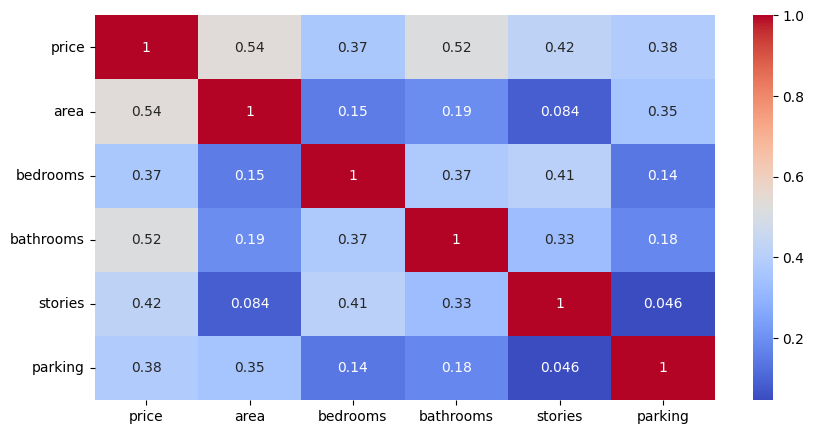

In [56]:
plt.figure(figsize=(10,5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm")
plt.show()

- **Area**, **bathrooms**, and **stories** have a **moderate positive correlation** with the target variable (`price`).
- **Bedrooms** and **parking** show a **weak positive correlation** with `price`.
- No pair of numerical features has a correlation greater than **0.8**, indicating **no strong multicollinearity**.